# Gộp dataset – DsPCBSD+_balanced + DeepPCB + HRIPCB

**Giả thiết (đã xử lý từ trước):**
- Cả 3 dataset dùng **cùng 6 class** với **cùng class ID** → không cần remap
- Cả 3 đã chia sẵn `train / valid / test` theo tỷ lệ 70/10/20

**Pipeline:**
1. Khám phá & đếm phân bố từng dataset
2. Copy toàn bộ, **prefix tên file** để tránh conflict
3. Tạo `data.yaml` cho merged dataset
4. Verify + visualize

## 1. Import & Config

In [1]:
import cv2
import yaml
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from collections import defaultdict
from tqdm import tqdm

random.seed(42)
np.random.seed(42)

# ── Thư mục ────────────────────────────────────────────────────
BASE_DIR   = Path("../data/processed")
OUTPUT_DIR = BASE_DIR / "PCB_merged"

# prefix ngắn → dùng để đặt tên file trong merged dataset
DATASETS = {
    "ds" : BASE_DIR / "DsPCBSD+_balanced",
    "dp" : BASE_DIR / "DeepPCB",
    "hr" : BASE_DIR / "HRIPCB",
}

SPLITS      = ["train", "valid", "test"]
IMG_EXTS    = {".jpg", ".jpeg", ".png", ".bmp"}

CLASS_NAMES = ["open", "short", "mousebite", "spur", "copper", "missing_hole"]
NUM_CLASSES = len(CLASS_NAMES)

DEFECT_COLORS = {
    "open":         "#E74C3C",
    "short":        "#3498DB",
    "mousebite":    "#2ECC71",
    "spur":         "#F39C12",
    "copper":       "#9B59B6",
    "missing_hole": "#1ABC9C",
    "unknown":      "#95A5A6",
}

print(f"OUTPUT_DIR : {OUTPUT_DIR.resolve()}")
for prefix, path in DATASETS.items():
    ok = "OK" if path.exists() else "KHÔNG TÌM THẤY"
    print(f"  [{prefix}] {path.name:<30} {ok}")

OUTPUT_DIR : D:\pcb-defect-detection\data\processed\PCB_merged
  [ds] DsPCBSD+_balanced              OK
  [dp] DeepPCB                        OK
  [hr] HRIPCB                         OK


## 2. Utility Functions

In [2]:
def resolve_split_dirs(root: Path, split: str):
    """Hỗ trợ layout root/images/split và root/split/images."""
    for img_d, lbl_d in [
        (root / "images" / split, root / "labels" / split),
        (root / split / "images", root / split / "labels"),
    ]:
        if img_d.exists():
            return img_d, lbl_d
    return root / "images" / split, root / "labels" / split


def read_labels(path: Path):
    boxes = []
    if path.exists():
        with open(path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    boxes.append([int(parts[0])] + [float(p) for p in parts[1:]])
    return boxes


def count_distribution(root: Path):
    """Đếm bbox/class cho từng split."""
    stats = {}
    for split in SPLITS:
        _, lbl_dir = resolve_split_dirs(root, split)
        counts = defaultdict(int)
        if lbl_dir.exists():
            for f in lbl_dir.glob("*.txt"):
                with open(f) as fp:
                    for line in fp:
                        parts = line.strip().split()
                        if parts:
                            counts[int(parts[0])] += 1
        stats[split] = counts
    return stats


print("Utility functions loaded.")

Utility functions loaded.


## 3. Phân bố từng dataset trước khi merge

          Class      ds/train    ds/valid     ds/test    dp/train    dp/valid     dp/test    hr/train    hr/valid     hr/test
-------------------------------------------------------------------------------------------------------------------------------
           open          2500         167         350        1409         195         338         345          49          88
          short          2554          85         176        1106         151         249         317          71         103
      mousebite          3100         238         542        1401         193         371         367          29          96
           spur          3126         497         961        1161         169         295         312          43         133
         copper          2905         136         306        1051         141         282         357          70          76
   missing_hole          2971         288         592        1038         154         309         376          36   

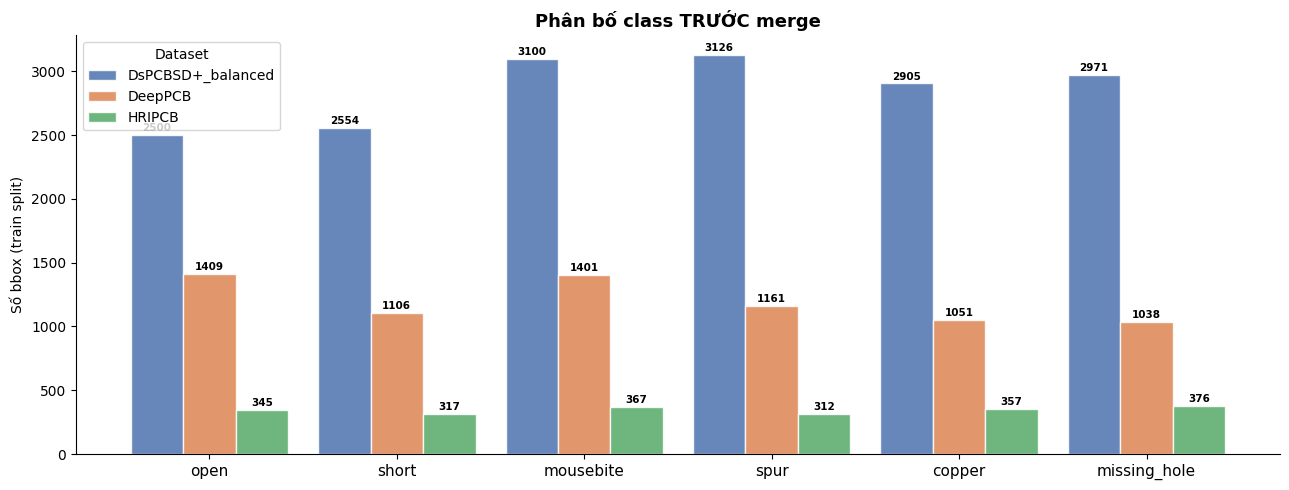

In [3]:
pre_stats = {prefix: count_distribution(path) for prefix, path in DATASETS.items()}

# ── Bảng số liệu ──────────────────────────────────────────────
print(f"{'Class':>15}  ", end="")
for prefix in DATASETS:
    for s in ["train", "valid", "test"]:
        print(f"{prefix+'/'+s:>12}", end="")
print()
print("-" * (15 + 12 * 3 * len(DATASETS) + 4))
for uid, name in enumerate(CLASS_NAMES):
    print(f"{name:>15}  ", end="")
    for prefix in DATASETS:
        for split in SPLITS:
            print(f"{pre_stats[prefix][split].get(uid, 0):>12}", end="")
    print()

# ── Bar chart – train split, nhóm theo dataset ────────────────
x       = np.arange(NUM_CLASSES)
width   = 0.28
palette = ["#4C72B0", "#DD8452", "#55A868"]
fig, ax = plt.subplots(figsize=(13, 5))

for i, (prefix, path) in enumerate(DATASETS.items()):
    vals   = [pre_stats[prefix]["train"].get(c, 0) for c in range(NUM_CLASSES)]
    offset = (i - 1) * width
    bars   = ax.bar(x + offset, vals, width, label=path.name,
                    color=palette[i], alpha=0.85, edgecolor="white")
    for bar, v in zip(bars, vals):
        if v > 0:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 15, str(v),
                    ha="center", va="bottom", fontsize=7.5, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, fontsize=11)
ax.set_ylabel("Số bbox (train split)")
ax.set_title("Phân bố class TRƯỚC merge", fontsize=13, fontweight="bold")
ax.legend(title="Dataset")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 4. Merge – Copy & Prefix

In [4]:
def merge_split(split: str, datasets: dict, dst_root: Path):
    dst_img = dst_root / "images" / split
    dst_lbl = dst_root / "labels" / split
    dst_img.mkdir(parents=True, exist_ok=True)
    dst_lbl.mkdir(parents=True, exist_ok=True)

    summary = {}
    for prefix, src_root in datasets.items():
        src_img, src_lbl = resolve_split_dirs(src_root, split)
        if not src_img.exists():
            print(f"  [{prefix}/{split}] Không tìm thấy {src_img}")
            summary[prefix] = {"imgs": 0, "bboxes": 0}
            continue

        imgs     = sorted(p for p in src_img.iterdir() if p.suffix.lower() in IMG_EXTS)
        n_imgs   = 0
        n_bboxes = 0

        for img_p in tqdm(imgs, desc=f"  [{prefix}/{split}]", leave=False):
            new_stem  = f"{prefix}_{img_p.stem}"

            # Image
            dst_img_p = dst_img / f"{new_stem}.jpg"
            if img_p.suffix.lower() in (".jpg", ".jpeg"):
                shutil.copy2(img_p, dst_img_p)
            else:
                img = cv2.imread(str(img_p))
                if img is None:
                    continue
                cv2.imwrite(str(dst_img_p), img, [cv2.IMWRITE_JPEG_QUALITY, 95])

            # Label
            src_lbl_p = src_lbl / (img_p.stem + ".txt")
            dst_lbl_p = dst_lbl / f"{new_stem}.txt"
            if src_lbl_p.exists():
                shutil.copy2(src_lbl_p, dst_lbl_p)
                with open(dst_lbl_p) as f:
                    n_bboxes += sum(1 for line in f if line.strip())
            else:
                dst_lbl_p.touch()

            n_imgs += 1

        summary[prefix] = {"imgs": n_imgs, "bboxes": n_bboxes}
        print(f"  [{prefix}/{split}] {n_imgs:5d} ảnh | {n_bboxes:6d} bboxes")

    return summary


if OUTPUT_DIR.exists():
    print(f"[INFO] Xóa thư mục cũ: {OUTPUT_DIR}")
    shutil.rmtree(OUTPUT_DIR)

merge_summary = {}
for split in SPLITS:
    print(f"\n{'='*45}  {split.upper()}")
    merge_summary[split] = merge_split(split, DATASETS, OUTPUT_DIR)

print("\nMerge hoàn tất!")


=============================================  TRAIN


  [ds/train]  8476 ảnh |  17156 bboxes


  [dp/train]  1050 ảnh |   7166 bboxes


  [hr/train]   485 ảnh |   2074 bboxes

=============================================  VALID


  [ds/valid]   718 ảnh |   1411 bboxes


  [dp/valid]   150 ảnh |   1003 bboxes


  [hr/valid]    69 ảnh |    298 bboxes

=============================================  TEST


  [ds/test]  1448 ảnh |   2927 bboxes


  [dp/test]   300 ảnh |   1844 bboxes


  [hr/test]   139 ảnh |    581 bboxes

Merge hoàn tất!


## 5. Tạo data.yaml

In [5]:
yaml_cfg = {
    "path":  str(OUTPUT_DIR.resolve()),
    "train": "images/train",
    "val":   "images/valid",
    "test":  "images/test",
    "nc":    NUM_CLASSES,
    "names": CLASS_NAMES,
}

yaml_out = OUTPUT_DIR / "data.yaml"
with open(yaml_out, "w") as f:
    yaml.dump(yaml_cfg, f, default_flow_style=False, allow_unicode=True)

print(f"data.yaml ghi tại: {yaml_out}")
print(yaml.dump(yaml_cfg, default_flow_style=False))

data.yaml ghi tại: ..\data\processed\PCB_merged\data.yaml
names:
- open
- short
- mousebite
- spur
- copper
- missing_hole
nc: 6
path: D:\pcb-defect-detection\data\processed\PCB_merged
test: images/test
train: images/train
val: images/valid



## 6. Phân bố sau merge

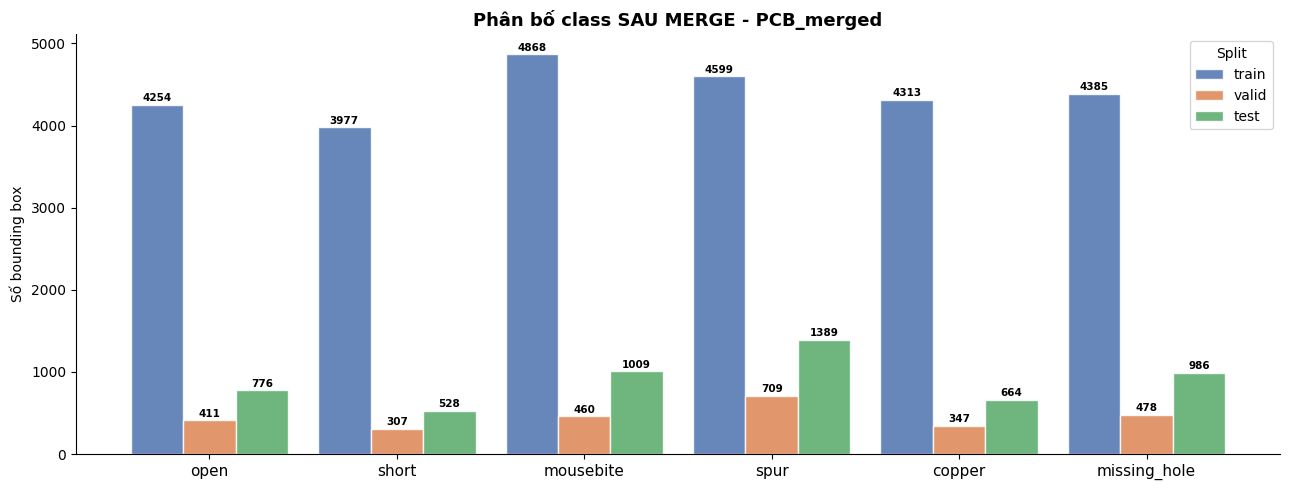

In [6]:
post_stats = count_distribution(OUTPUT_DIR)

x       = np.arange(NUM_CLASSES)
width   = 0.28
palette = ["#4C72B0", "#DD8452", "#55A868"]
fig, ax = plt.subplots(figsize=(13, 5))

for i, split in enumerate(SPLITS):
    vals   = [post_stats[split].get(c, 0) for c in range(NUM_CLASSES)]
    offset = (i - 1) * width
    bars   = ax.bar(x + offset, vals, width, label=split,
                    color=palette[i], alpha=0.85, edgecolor="white")
    for bar, v in zip(bars, vals):
        if v > 0:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 20, str(v),
                    ha="center", va="bottom", fontsize=7.5, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, fontsize=11)
ax.set_ylabel("Số bounding box")
ax.set_title("Phân bố class SAU MERGE - PCB_merged", fontsize=13, fontweight="bold")
ax.legend(title="Split")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 7. Visualize – Mẫu ảnh từng dataset

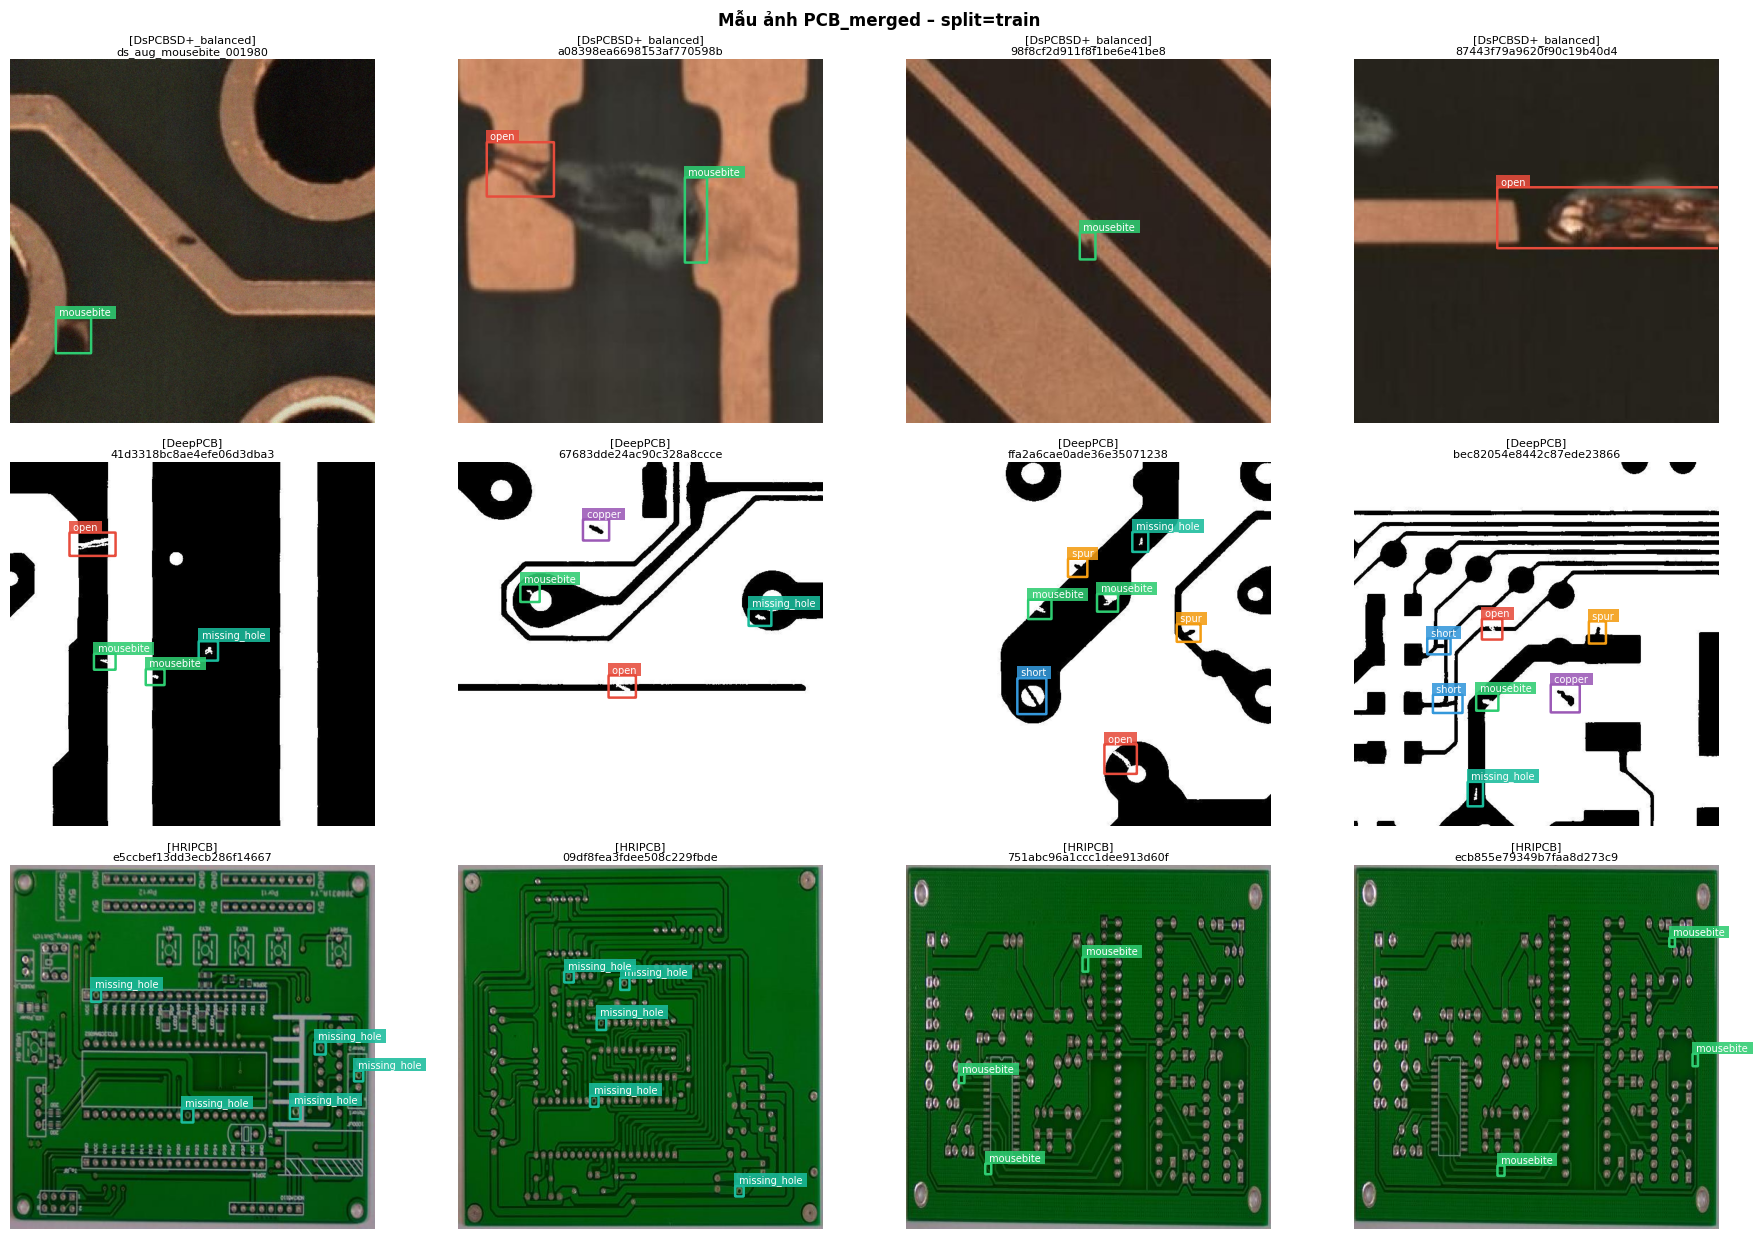

In [7]:
def draw_yolo_boxes(ax, image_rgb: np.ndarray, boxes: list, title: str = ""):
    ax.imshow(image_rgb)
    ax.set_title(title, fontsize=8, pad=3)
    ax.axis("off")
    h, w = image_rgb.shape[:2]
    for b in boxes:
        cls_id = int(b[0])
        cx, cy, bw_n, bh_n = b[1], b[2], b[3], b[4]
        label  = CLASS_NAMES[cls_id] if cls_id < NUM_CLASSES else f"id:{cls_id}"
        color  = DEFECT_COLORS.get(label, DEFECT_COLORS["unknown"])
        x1     = (cx - bw_n / 2) * w
        y1     = (cy - bh_n / 2) * h
        rect   = mpatches.FancyBboxPatch(
            (x1, y1), bw_n * w, bh_n * h,
            boxstyle="round,pad=1", linewidth=1.8,
            edgecolor=color, facecolor="none",
        )
        ax.add_patch(rect)
        ax.text(
            x1, max(0, y1 - 2), f" {label} ",
            fontsize=7, color="white", va="bottom", ha="left",
            bbox=dict(facecolor=color, edgecolor="none", alpha=0.88, pad=1.0),
        )


def show_samples_by_source(merged_dir: Path, split: str = "train", n_per_ds: int = 4):
    img_dir = merged_dir / "images" / split
    lbl_dir = merged_dir / "labels" / split

    groups = defaultdict(list)
    for p in img_dir.iterdir():
        if p.suffix.lower() in IMG_EXTS:
            groups[p.stem.split("_")[0]].append(p)

    prefixes = [p for p in DATASETS if p in groups]
    rows, cols = len(prefixes), n_per_ds
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4.5, rows * 4.2))
    if rows == 1:
        axes = axes[np.newaxis, :]

    ds_name_map = {p: path.name for p, path in DATASETS.items()}

    for ri, prefix in enumerate(prefixes):
        samples = random.sample(groups[prefix], min(n_per_ds, len(groups[prefix])))
        for ci in range(cols):
            ax = axes[ri, ci]
            if ci >= len(samples):
                ax.axis("off")
                continue
            img_p = samples[ci]
            img   = cv2.imread(str(img_p))
            if img is None:
                ax.axis("off")
                continue
            boxes = read_labels(lbl_dir / (img_p.stem + ".txt"))
            title = f"[{ds_name_map.get(prefix, prefix)}]\n{img_p.stem[-24:]}"
            draw_yolo_boxes(ax, cv2.cvtColor(img, cv2.COLOR_BGR2RGB), boxes, title)

    plt.suptitle(f"Mẫu ảnh PCB_merged – split={split}",
                 fontweight="bold", fontsize=12)
    plt.tight_layout()
    plt.show()


show_samples_by_source(OUTPUT_DIR, split="train", n_per_ds=4)

## 8. Verification

In [8]:
def verify_dataset(root: Path):
    total_errors = 0
    for split in SPLITS:
        img_dir = root / "images" / split
        lbl_dir = root / "labels" / split
        if not img_dir.exists():
            continue
        errors = []
        imgs   = [p for p in img_dir.iterdir() if p.suffix.lower() in IMG_EXTS]
        for img_p in imgs:
            lbl_p = lbl_dir / (img_p.stem + ".txt")
            if not lbl_p.exists():
                errors.append(f"Thiếu label: {img_p.name}")
                continue
            for i, b in enumerate(read_labels(lbl_p)):
                cls, cx, cy, bw, bh = b
                if not (0 <= cx <= 1 and 0 <= cy <= 1 and 0 < bw <= 1 and 0 < bh <= 1):
                    errors.append(f"{lbl_p.name} box[{i}] ngoài biên: {b}")
                if cls < 0 or cls >= NUM_CLASSES:
                    errors.append(f"{lbl_p.name} box[{i}] class_id không hợp lệ: {cls}")

        status = "Tất cả hợp lệ" if not errors else f"{len(errors)} lỗi"
        print(f"  [{split:6s}] {len(imgs):6d} ảnh  ->  {status}")
        for e in errors[:10]:
            print(f"     {e}")
        total_errors += len(errors)

    print()
    if total_errors == 0:
        print("Dataset hoàn toàn hợp lệ!")
    else:
        print(f"Tổng {total_errors} lỗi – kiểm tra lại.")


verify_dataset(OUTPUT_DIR)

  [train ]  10011 ảnh  ->  Tất cả hợp lệ
  [valid ]    937 ảnh  ->  Tất cả hợp lệ
  [test  ]   1887 ảnh  ->  Tất cả hợp lệ

Dataset hoàn toàn hợp lệ!


## 9. Tóm tắt kết quả

In [9]:
print("\n" + "="*57)
print(" " * 20 + "TÓM TẮT PCB_merged")
print("="*57)

prefixes = list(DATASETS.keys())

# ── Số ảnh theo dataset x split ───────────────────────────────
print(f"\n  {'':>15}", end="")
for p in prefixes:
    print(f"{p:>10}", end="")
print(f"  {'TOTAL':>8}")
print("-" * (15 + 10 * len(prefixes) + 12))
for split in SPLITS:
    row_sum = sum(merge_summary[split][p]["imgs"] for p in prefixes)
    print(f"  {split:>15}", end="")
    for p in prefixes:
        print(f"{merge_summary[split][p]['imgs']:>10}", end="")
    print(f"  {row_sum:>8}")

# ── Số bbox theo class x split ────────────────────────────────
print(f"\n  {'Class':>15}  {'train':>8}  {'valid':>8}  {'test':>8}  {'TOTAL':>8}")
print("-" * 57)
grand_total = 0
for uid, name in enumerate(CLASS_NAMES):
    row   = [post_stats[s].get(uid, 0) for s in SPLITS]
    total = sum(row)
    grand_total += total
    print(f"  {name:>15}  {row[0]:>8}  {row[1]:>8}  {row[2]:>8}  {total:>8}")
print("-" * 57)
foot = [sum(post_stats[s].values()) for s in SPLITS]
print(f"  {'TOTAL':>15}  {foot[0]:>8}  {foot[1]:>8}  {foot[2]:>8}  {grand_total:>8}")

print("="*57)


                    TÓM TẮT PCB_merged

                         ds        dp        hr     TOTAL
---------------------------------------------------------
            train      8476      1050       485     10011
            valid       718       150        69       937
             test      1448       300       139      1887

            Class     train     valid      test     TOTAL
---------------------------------------------------------
             open      4254       411       776      5441
            short      3977       307       528      4812
        mousebite      4868       460      1009      6337
             spur      4599       709      1389      6697
           copper      4313       347       664      5324
     missing_hole      4385       478       986      5849
---------------------------------------------------------
            TOTAL     26396      2712      5352     34460
